# LeetCode-Domain Threshold Distribution Check

This notebook uses only the official Task A **training split**, which represents the seen-language / seen-domain setting: C++, Python, Java algorithmic code.

Experiment design:
- sample **2000 LeetCode-domain training rows** to fit single and double thresholds
- sample **1000 different LeetCode-domain rows** as a held-out same-domain test subset
- compute Fast-DetectGPT discrepancy scores for both subsets
- plot score histograms with fitted normal curves for human and machine code

No official challenge test split is loaded or used.


## Environment Setup

We check if the notebook is running in Google Colab and install the necessary libraries (`transformers`, `datasets`, `accelerate`, etc.).

In [9]:
# Check environment and install dependencies
import os
import sys

IS_COLAB = "COLAB_GPU" in os.environ or "google.colab" in sys.modules
print(f"Running on {'Google Colab' if IS_COLAB else 'Local Machine'}")

if IS_COLAB:
    print("Installing requirements for Google Colab...")
    !pip install -q "datasets==4.3.0" "huggingface_hub>=0.34.0" transformers accelerate pandas pyarrow tqdm scikit-learn matplotlib seaborn torch
else:
    print("Local environment detected. Please ensure you have transformers, datasets, torch, pandas, scikit-learn, matplotlib, and seaborn installed.")


Running on Google Colab
Installing requirements for Google Colab...


## Configuration

Set the model, fixed sample sizes, and random seed for the train-only threshold experiment.


In [10]:
# Task A Configuration
DATASET_NAME = "DaniilOr/SemEval-2026-Task13"
DATASET_CONFIG = "A"
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"

# LeetCode-domain train-only experiment sizes.
THRESHOLD_FIT_SAMPLES = 2000
LEETCODE_TEST_SAMPLES = 1000
THRESHOLD_GRID_SIZE = 200
MAX_LENGTH = 512
SEED = 99

import random
import numpy as np
import torch

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


## Load Tokenizer and Model

We load the causal language model with automatic precision setting (preferring `bfloat16` if supported by hardware, or `float16` as standard) to optimize memory consumption and speed.

In [11]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

print(f"Loading Tokenizer for {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Loading Model for {MODEL_NAME}...")
# Use float16 or bfloat16 to optimize memory and speed
torch_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch_dtype,
    device_map="auto" if device == "cuda" else None,
    trust_remote_code=True
)
model.eval()
print("Model loaded successfully!")

Using device: cuda
Loading Tokenizer for codellama/CodeLlama-7b-Instruct-hf...
Loading Model for codellama/CodeLlama-7b-Instruct-hf...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded successfully!


## Fast-DetectGPT Score

Compute the analytic Fast-DetectGPT sampling discrepancy used by the threshold classifiers.


In [12]:
def get_sampling_discrepancy_analytic(logits_ref, logits_score, labels):
    assert logits_ref.shape[0] == 1
    assert logits_score.shape[0] == 1
    assert labels.shape[0] == 1

    if logits_ref.size(-1) != logits_score.size(-1):
        vocab_size = min(logits_ref.size(-1), logits_score.size(-1))
        logits_ref = logits_ref[:, :, :vocab_size]
        logits_score = logits_score[:, :, :vocab_size]

    labels = labels.unsqueeze(-1) if labels.ndim == logits_score.ndim - 1 else labels
    lprobs_score = torch.log_softmax(logits_score, dim=-1)
    probs_ref = torch.softmax(logits_ref, dim=-1)

    log_likelihood = lprobs_score.gather(dim=-1, index=labels).squeeze(-1)
    mean_ref = (probs_ref * lprobs_score).sum(dim=-1)
    var_ref = (probs_ref * torch.square(lprobs_score)).sum(dim=-1) - torch.square(mean_ref)

    discrepancy = (log_likelihood.sum(dim=-1) - mean_ref.sum(dim=-1)) / (var_ref.sum(dim=-1).sqrt() + 1e-8)
    return discrepancy.mean().item()


## Load Training Dataset

Only the official training split is loaded. The threshold-fitting and held-out evaluation subsets are sampled from this split without overlap.


In [13]:
import pandas as pd
from datasets import load_dataset

print(f"Loading official SemEval dataset '{DATASET_NAME}' (Task {DATASET_CONFIG}) training split...")
train_dataset = load_dataset(DATASET_NAME, DATASET_CONFIG, split="train")
train_df = train_dataset.to_pandas().dropna(subset=["code", "label"]).copy()
train_df["label"] = train_df["label"].astype(int)

print(f"Training dataset loaded: {len(train_df)} rows")
print("\nTraining label distribution:")
print(train_df["label"].value_counts().sort_index())
print("\nSample code snippet:")
print(train_df["code"].iloc[0][:300] + "...")


Loading official SemEval dataset 'DaniilOr/SemEval-2026-Task13' (Task A) training split...
Training dataset loaded: 500000 rows

Training label distribution:
label
0    238475
1    261525
Name: count, dtype: int64

Sample code snippet:
(a, b, c, d) = [int(x) for x in input().split()]
k = input()
(p, q, r, s) = (0, 0, 0, 0)
for i in k:
	if i == '1':
		p += 1
	elif i == '2':
		q += 1
	elif i == '3':
		r += 1
	elif i == '4':
		s += 1
print(a * p + b * q + c * r + d * s)
...


## Split LeetCode-Domain Rows and Compute Scores

Build one fixed stratified threshold-fitting subset and one disjoint fixed held-out subset from the official training split.


In [14]:
from tqdm.auto import tqdm


def make_stratified_train_holdout_split(df, fit_samples, test_samples, seed):
    if fit_samples % 2 != 0 or test_samples % 2 != 0:
        raise ValueError("fit_samples and test_samples must be even for balanced binary splits.")

    fit_per_class = fit_samples // 2
    test_per_class = test_samples // 2
    fit_parts = []
    test_parts = []

    for label in [0, 1]:
        label_df = df[df["label"] == label].sample(frac=1.0, random_state=seed + label)
        required = fit_per_class + test_per_class
        if len(label_df) < required:
            raise ValueError(f"Not enough rows for label {label}: need {required}, found {len(label_df)}")

        fit_parts.append(label_df.iloc[:fit_per_class].copy())
        test_parts.append(label_df.iloc[fit_per_class:required].copy())

    fit_df = pd.concat(fit_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    test_df = pd.concat(test_parts).sample(frac=1.0, random_state=seed + 1).reset_index(drop=True)
    return fit_df, test_df


def compute_discrepancy_for_df(df, desc="Computing Discrepancy"):
    scores = []

    for row in tqdm(df.to_dict("records"), total=len(df), desc=desc):
        tokenized = tokenizer(
            row["code"],
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH,
            return_token_type_ids=False,
        ).to(device)

        if tokenized.input_ids.shape[1] <= 5:
            scores.append(0.0)
            continue

        labels = tokenized.input_ids[:, 1:]

        with torch.no_grad():
            logits = model(**tokenized).logits[:, :-1]
            try:
                score = get_sampling_discrepancy_analytic(logits, logits, labels)
            except Exception:
                score = 0.0
            scores.append(score)

    scored_df = df.copy()
    scored_df["discrepancy_score"] = scores
    return scored_df


threshold_fit_source_df, leetcode_test_source_df = make_stratified_train_holdout_split(
    train_df,
    fit_samples=THRESHOLD_FIT_SAMPLES,
    test_samples=LEETCODE_TEST_SAMPLES,
    seed=SEED,
)

print("Threshold fitting rows:")
print(threshold_fit_source_df["label"].value_counts().sort_index())
print("\nHeld-out LeetCode rows:")
print(leetcode_test_source_df["label"].value_counts().sort_index())

fit_df = compute_discrepancy_for_df(
    threshold_fit_source_df,
    desc=f"Scoring {THRESHOLD_FIT_SAMPLES} threshold-fit LeetCode rows",
)
leetcode_test_df = compute_discrepancy_for_df(
    leetcode_test_source_df,
    desc=f"Scoring {LEETCODE_TEST_SAMPLES} held-out LeetCode rows",
)


Threshold fitting rows:
label
0    1000
1    1000
Name: count, dtype: int64

Held-out LeetCode rows:
label
0    500
1    500
Name: count, dtype: int64


Scoring 2000 threshold-fit LeetCode rows:   0%|          | 0/2000 [00:00<?, ?it/s]

Scoring 1000 held-out LeetCode rows:   0%|          | 0/1000 [00:00<?, ?it/s]

## Fit Thresholds on 2000 LeetCode Rows

Fit single and double thresholds on the 2000-row subset, then evaluate both strategies on the fixed disjoint 1000-row held-out subset.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, classification_report


def fit_single_threshold(y_true, y_scores, grid_size):
    thresholds = np.linspace(np.min(y_scores), np.max(y_scores), grid_size)
    best_threshold = thresholds[0]
    best_f1 = -1.0

    for threshold in thresholds:
        preds = (y_scores > threshold).astype(int)
        f1 = f1_score(y_true, preds, average="macro")
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    return best_threshold, best_f1, thresholds


def fit_double_threshold(y_true, y_scores, thresholds, single_threshold, single_f1):
    best_lower = np.min(y_scores)
    best_upper = single_threshold
    best_f1 = single_f1

    for upper in thresholds:
        for lower in thresholds:
            if lower >= upper:
                continue
            preds = ((y_scores < lower) | (y_scores > upper)).astype(int)
            f1 = f1_score(y_true, preds, average="macro")
            if f1 > best_f1:
                best_f1 = f1
                best_lower = lower
                best_upper = upper

    return best_lower, best_upper, best_f1


def predict_single(scores, threshold):
    return (scores > threshold).astype(int)


def predict_double(scores, lower, upper):
    return ((scores < lower) | (scores > upper)).astype(int)


fit_y = fit_df["label"].astype(int).values
fit_scores = fit_df["discrepancy_score"].values

best_single_threshold, fit_single_f1, threshold_grid = fit_single_threshold(
    fit_y,
    fit_scores,
    THRESHOLD_GRID_SIZE,
)
best_double_lower, best_double_upper, fit_double_f1 = fit_double_threshold(
    fit_y,
    fit_scores,
    threshold_grid,
    best_single_threshold,
    fit_single_f1,
)

leetcode_test_y = leetcode_test_df["label"].astype(int).values
leetcode_test_scores = leetcode_test_df["discrepancy_score"].values
leetcode_test_single_preds = predict_single(leetcode_test_scores, best_single_threshold)
leetcode_test_double_preds = predict_double(leetcode_test_scores, best_double_lower, best_double_upper)
leetcode_test_single_f1 = f1_score(leetcode_test_y, leetcode_test_single_preds, average="macro")
leetcode_test_double_f1 = f1_score(leetcode_test_y, leetcode_test_double_preds, average="macro")

print(f"Single threshold fitted on 2000 rows: {best_single_threshold:.4f}")
print(f"Double threshold fitted on 2000 rows: lower={best_double_lower:.4f}, upper={best_double_upper:.4f}")
print(f"Fit Macro F1: single={fit_single_f1:.4f}, double={fit_double_f1:.4f}")
print("\nMacro F1 on fixed 1000-row held-out LeetCode split:")
print(f"  Single threshold: {leetcode_test_single_f1:.4f}")
print(f"  Double threshold: {leetcode_test_double_f1:.4f}")
print(f"  Delta double-single: {leetcode_test_double_f1 - leetcode_test_single_f1:+.4f}")

print("\nHeld-out LeetCode classification report: single threshold")
print(classification_report(leetcode_test_y, leetcode_test_single_preds, target_names=["human", "machine"]))
print("\nHeld-out LeetCode classification report: double threshold")
print(classification_report(leetcode_test_y, leetcode_test_double_preds, target_names=["human", "machine"]))


Single threshold fitted on 2000 rows: 0.3288
Double threshold fitted on 2000 rows: lower=-1.5344, upper=0.6837
Fit Macro F1: single=0.5380, double=0.6213

Macro F1 on fixed 1000-row held-out LeetCode split:
  Single threshold: 0.5097
  Double threshold: 0.5942
  Delta double-single: +0.0846

Held-out LeetCode classification report: single threshold
              precision    recall  f1-score   support

       human       0.52      0.69      0.59       500
     machine       0.53      0.36      0.43       500

    accuracy                           0.52      1000
   macro avg       0.53      0.52      0.51      1000
weighted avg       0.53      0.52      0.51      1000


Held-out LeetCode classification report: double threshold
              precision    recall  f1-score   support

       human       0.58      0.68      0.63       500
     machine       0.62      0.51      0.56       500

    accuracy                           0.60      1000
   macro avg       0.60      0.60      0.59  

## Normal Distribution Plots

These plots show discrepancy-score histograms with fitted normal curves for human and machine samples. The fitted single and double thresholds are drawn as vertical reference lines.


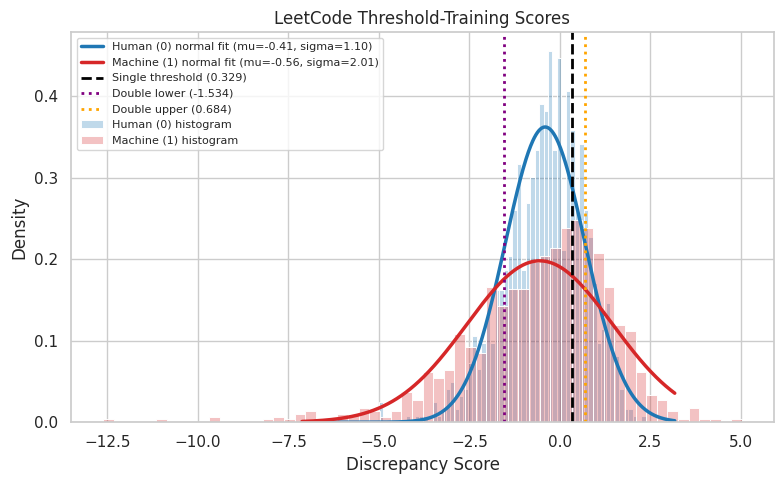

In [16]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
ax = plt.gca()


def normal_pdf(x, mean, std):
    if std <= 0:
        return np.zeros_like(x)
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))


def plot_normal_distribution(ax, plot_df, title):
    colors = {0: "#1f77b4", 1: "#d62728"}
    names = {0: "Human (0)", 1: "Machine (1)"}
    all_scores = plot_df["discrepancy_score"].dropna().values
    x_min, x_max = np.percentile(all_scores, [0.5, 99.5])
    x_grid = np.linspace(x_min, x_max, 500)

    for label in [0, 1]:
        scores = plot_df[plot_df["label"] == label]["discrepancy_score"].dropna().values
        mean = np.mean(scores)
        std = np.std(scores, ddof=1)
        sns.histplot(
            scores,
            color=colors[label],
            label=f"{names[label]} histogram",
            stat="density",
            bins=60,
            alpha=0.28,
            ax=ax,
        )
        ax.plot(
            x_grid,
            normal_pdf(x_grid, mean, std),
            color=colors[label],
            linewidth=2.5,
            label=f"{names[label]} normal fit (mu={mean:.2f}, sigma={std:.2f})",
        )

    ax.axvline(best_single_threshold, color="black", linestyle="--", linewidth=2, label=f"Single threshold ({best_single_threshold:.3f})")
    ax.axvline(best_double_lower, color="purple", linestyle=":", linewidth=2, label=f"Double lower ({best_double_lower:.3f})")
    ax.axvline(best_double_upper, color="orange", linestyle=":", linewidth=2, label=f"Double upper ({best_double_upper:.3f})")
    ax.set_title(title)
    ax.set_xlabel("Discrepancy Score")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)


plot_normal_distribution(ax, fit_df, "LeetCode Threshold-Training Scores")

plt.tight_layout()
plt.show()
